# Targets generation

In [1]:
import numpy as np
from src.targets_generation import Gaussian_seq

In [2]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = np.sqrt(0.3) # width of the gaussian curve
epsilon = 0.05

Choice of sigma: must be bigger than dt and smaller than T. Furthermore, sigma/T ~= N_active/N, which is equal to 0.3 as per the authors.

In [3]:
gs = Gaussian_seq(T, dt)
targets = gs.target_functions(T, sigma, N, epsilon)

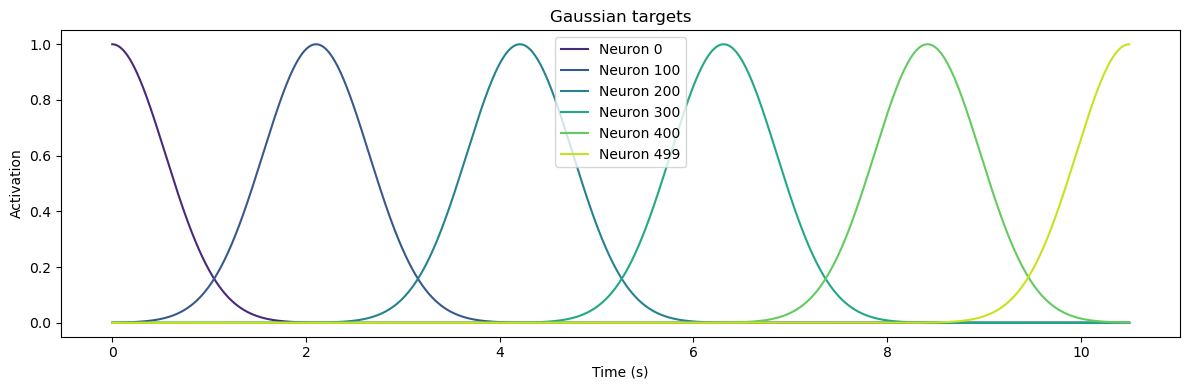

In [4]:
gs.gaussian_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499])

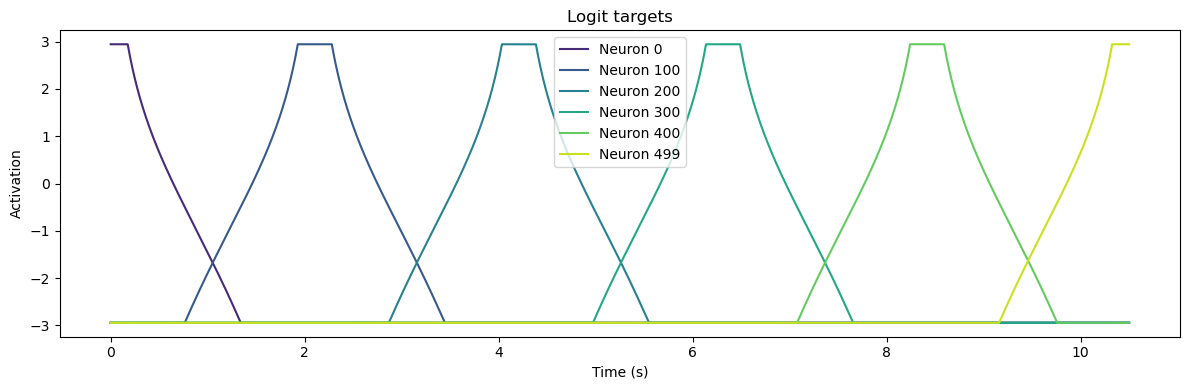

In [5]:
gs.target_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499], epsilon=epsilon)

# Inputs generation

In [6]:
from src.inputs_generation import Inputs

We define the external inputs of the network as filtered and spatially delocalized white noise, that is frozen, using this equation: \
$\tau_{WN} \displaystyle\frac{dh}{dt} = -h(t) + h_0 \eta (t)$,
for $\eta \sim \mathcal{N}(0, 1)$.

In [7]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 0.15 # inputs' scale

In [8]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

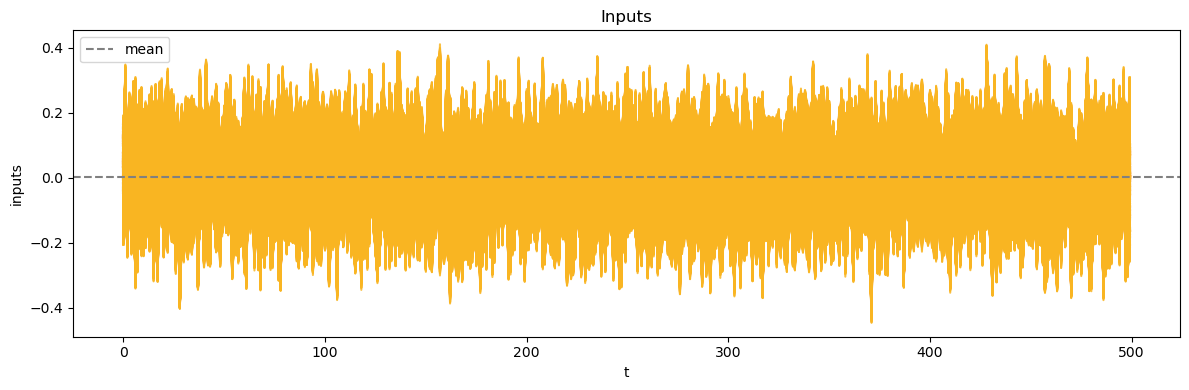

In [9]:
ipt.display_inputs(N, WN_tau, h0)

# Training

In [10]:
from src.training import RNN, PINning

Training parameters, fixed according to Rajan, Harvey & Tank (2016).

In [11]:
p = 0.08 # fraction of plastic synapses in the network
g = 1.5 # chaos parameter in [1.2, 1.5]
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.02 # error value at which we deem the model to converge
p_reg = 1e-9 # Ridge regularization parameter

Run 1 | run_error=0.032050 | ||J||=393.63 | Δ||J||=+0.00
Run 2 | run_error=0.073667 | ||J||=440.08 | Δ||J||=+46.45
Run 3 | run_error=0.073480 | ||J||=473.76 | Δ||J||=+33.68
Run 4 | run_error=0.075701 | ||J||=492.71 | Δ||J||=+18.95
Run 5 | run_error=0.055441 | ||J||=513.14 | Δ||J||=+20.43
Run 6 | run_error=0.066590 | ||J||=523.61 | Δ||J||=+10.47
Run 7 | run_error=0.065629 | ||J||=533.92 | Δ||J||=+10.31
Run 8 | run_error=0.068873 | ||J||=544.11 | Δ||J||=+10.19
Run 9 | run_error=0.057842 | ||J||=544.80 | Δ||J||=+0.69
Run 10 | run_error=0.060490 | ||J||=553.02 | Δ||J||=+8.22
Run 11 | run_error=0.052195 | ||J||=556.49 | Δ||J||=+3.47
Run 12 | run_error=0.059644 | ||J||=561.24 | Δ||J||=+4.75
Run 13 | run_error=0.056494 | ||J||=565.99 | Δ||J||=+4.76
Run 14 | run_error=0.051899 | ||J||=569.26 | Δ||J||=+3.26
Run 15 | run_error=0.049410 | ||J||=573.07 | Δ||J||=+3.81
Run 16 | run_error=0.063799 | ||J||=580.05 | Δ||J||=+6.98
Run 17 | run_error=0.045402 | ||J||=580.63 | Δ||J||=+0.58
Run 18 | run_err

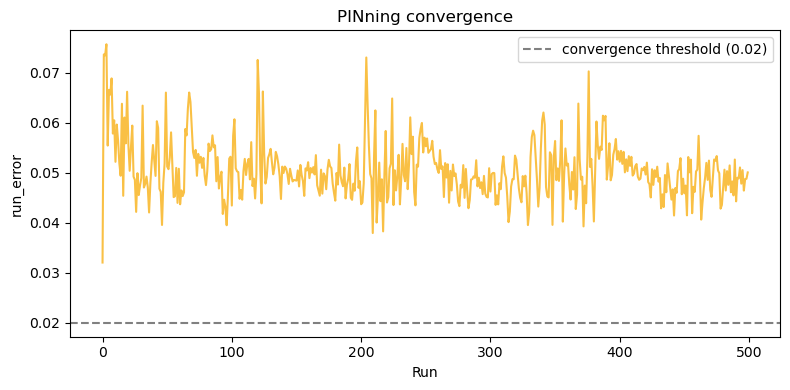

In [12]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg)
# print(np.linalg.eigvalsh(PINned_model.P).min())
PINned_model.display_cv(errors)

In [13]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

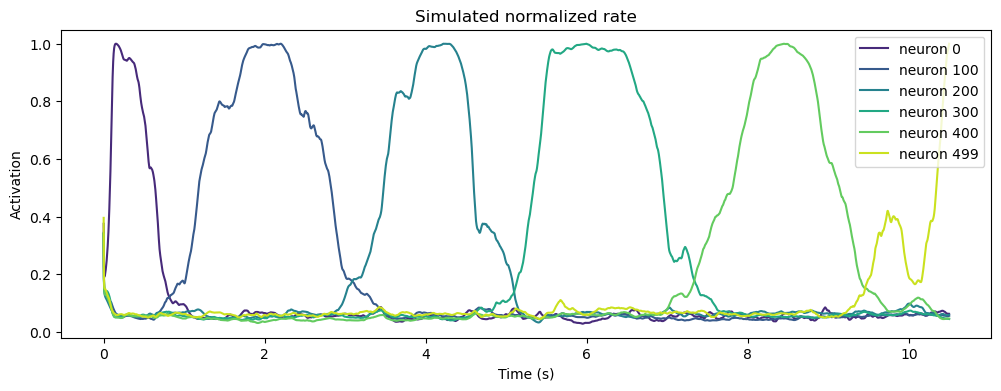

In [14]:
neuron_list = [0, 100, 200, 300, 400, 499]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

# Evaluation

In [15]:
threshold = 0.95

In [16]:
from src.evaluation import Metrics

In [17]:
from scipy.special import expit
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.648219,0.908321,8
1,Article's metrics for p=0.08,1,0.92,10


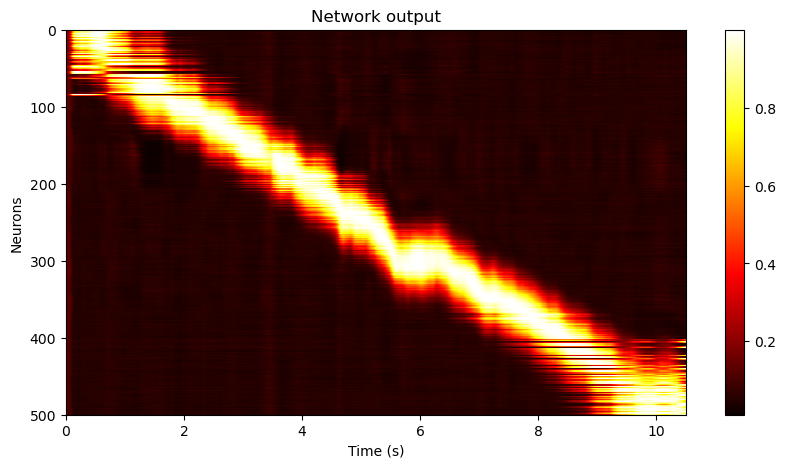

In [18]:
Metrics.network_output(final_rates, T, dt)

# Model logging

In [19]:
from datetime import datetime
model_path = f'model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npz'

In [20]:
PINned_model.save(model_path)

# Synapse activity analysis

In [21]:
model, inputs = PINning.load(model_path)

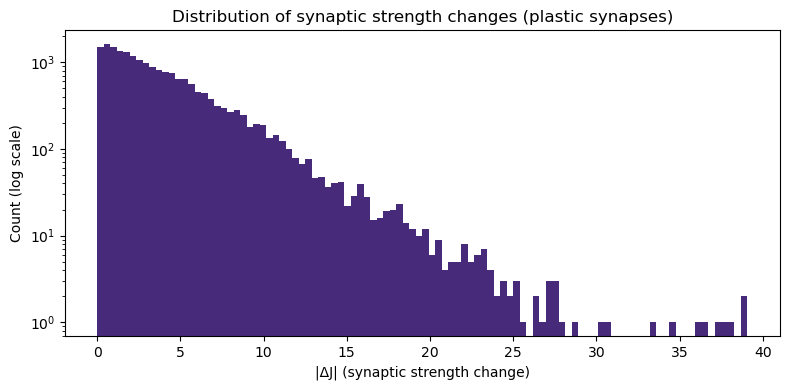

max / median |ΔJ| ratio: 13.3 (paper reports ~20 for a sparsely PINned network)


In [22]:
model.display_weight_change()

In [23]:
import numpy as np
print(np.load(model_path).files)

['J', 'J_init', 'inputs', 'targets', 'theta', 'dt', 'tau', 'N', 'g', 'p0', 'p', 'P', 'plastic_neurons']
